# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** Pankaj Singh Rawat 
**Student ID:** 2025ac05533
**Date:** 06-06-2026

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Fill in all values accurately** - these will be auto-verified
4. **After submission**, you'll receive a verification quiz based on YOUR results
5. **Run all cells** before submitting (Kernel → Restart & Run All)

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
# Load the Wisconsin Diagnostic Breast Cancer dataset
column_names = ['id', 'diagnosis'] + [f'{stat}_{feature}' for feature in ['radius','texture','perimeter','area','smoothness','compactness','concavity','concave_points','symmetry','fractal_dimension'] for stat in ['mean','se','worst']]
data = pd.read_csv('../data/wdbc.data', header=None, names=column_names)
dataset_name = 'Breast Cancer Wisconsin (Diagnostic)'
dataset_source = 'UCI ML Repository'
n_samples = data.shape[0]
n_features = data.shape[1] - 2  # exclude id and target
problem_type = 'binary_classification'
problem_statement = '''
This dataset predicts whether a breast tumor is malignant or benign from 30 numeric diagnostic measurements.
The prediction is important because early identification of malignant tumors improves treatment outcomes and reduces unnecessary procedures.
'''
primary_metric = 'recall'
metric_justification = '''
Recall is chosen because in medical diagnosis, failing to detect a malignant tumor (false negative) is more harmful than incorrectly flagging a benign case.
Maximizing recall helps prioritize patient safety and reduces the chance of missing a cancer diagnosis.
'''
# We use the diagnosis label as the binary target.
data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1})
print(f'Dataset: {dataset_name}')
print(f'Source: {dataset_source}')
print(f'Samples: {n_samples}, Features: {n_features}')
print(f'Problem Type: {problem_type}')
print(f'Primary Metric: {primary_metric}')


Dataset: Breast Cancer Wisconsin (Diagnostic)
Source: UCI ML Repository
Samples: 569, Features: 30
Problem Type: binary_classification
Primary Metric: recall


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [3]:
# Preprocess your data
# 1. Separate features (X) and target (y)
# 2. Handle missing values if any
# 3. Encode categorical variables

X = data.drop(['id', 'diagnosis'], axis=1)
y = data['diagnosis']

# Handle missing values if any (this dataset has none, but we keep the step for completeness)
if X.isnull().any().any():
    X = X.fillna(X.median())

# Encode categorical variables if required (none in this dataset)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill these after preprocessing
train_samples = X_train.shape[0]       # Number of training samples
test_samples = X_test.shape[0]        # Number of test samples
train_test_ratio = train_samples / (train_samples + test_samples)

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Train samples: 455
Test samples: 114
Split ratio: 80.0%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [4]:
class BaselineModel:
    """
    Baseline linear model with gradient descent for binary classification.
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []
        
        for i in range(self.n_iterations):
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_output)
            y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
            loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
            dw = np.dot(X.T, (y_pred - y)) / n_samples
            db = np.sum(y_pred - y) / n_samples
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            self.loss_history.append(loss)
        return self
    
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        probabilities = self.sigmoid(linear_output)
        return (probabilities >= 0.5).astype(int)

print('✓ Baseline model class defined')


✓ Baseline model class defined


In [5]:
# Preprocess the dataset
X = data.drop(['id', 'diagnosis'], axis=1)
y = data['diagnosis'].values

# No missing values are present in this dataset
train_test_ratio = 0.8
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_test_ratio, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_samples = X_train.shape[0]
test_samples = X_test.shape[0]

print(f'Train samples: {train_samples}')
print(f'Test samples: {test_samples}')
print(f'Split ratio: {train_test_ratio:.1%}')

print('Training baseline model...')
baseline_start_time = time.time()
baseline_model = BaselineModel(learning_rate=0.01, n_iterations=2000)
baseline_model.fit(X_train_scaled, y_train)
baseline_predictions = baseline_model.predict(X_test_scaled)
baseline_training_time = time.time() - baseline_start_time
print(f'✓ Baseline training completed in {baseline_training_time:.2f}s')
print(f'✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}')


Train samples: 455
Test samples: 114
Split ratio: 80.0%
Training baseline model...
✓ Baseline training completed in 0.04s
✓ Loss decreased from 0.6931 to 0.0856


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [6]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch for binary classification.
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        np.random.seed(42)
        for l in range(1, len(self.architecture)):
            input_dim = self.architecture[l - 1]
            output_dim = self.architecture[l]
            self.parameters[f'W{l}'] = np.random.randn(output_dim, input_dim) * 0.01
            self.parameters[f'b{l}'] = np.zeros((output_dim, 1))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        self.cache['A0'] = X
        A = X
        for l in range(1, len(self.architecture)):
            W = self.parameters[f'W{l}']
            b = self.parameters[f'b{l}']
            Z = np.dot(A, W.T) + b.T
            self.cache[f'Z{l}'] = Z
            if l < len(self.architecture) - 1:
                A = self.relu(Z)
            else:
                A = self.sigmoid(Z)
            self.cache[f'A{l}'] = A
        return A

    def backward_propagation(self, X, y):
        m = X.shape[0]
        y_true = y.reshape(-1, 1)
        grads = {}
        L = len(self.architecture) - 1
        A_final = self.cache[f'A{L}']
        dZ = A_final - y_true

        for l in reversed(range(1, L + 1)):
            A_prev = self.cache[f'A{l-1}']
            grads[f'dW{l}'] = np.dot(dZ.T, A_prev) / m
            grads[f'db{l}'] = np.mean(dZ, axis=0, keepdims=True).T
            if l > 1:
                W = self.parameters[f'W{l}']
                dA_prev = np.dot(dZ, W)
                dZ = dA_prev * self.relu_derivative(self.cache[f'Z{l-1}'])
        return grads

    def update_parameters(self, grads):
        for l in range(1, len(self.architecture)):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        y_true = y_true.reshape(-1, 1)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y):
        self.initialize_parameters()
        self.loss_history = []
        for i in range(self.n_iterations):
            y_pred = self.forward_propagation(X)
            loss = self.compute_loss(y_pred, y)
            grads = self.backward_propagation(X, y)
            self.update_parameters(grads)
            self.loss_history.append(loss)
        return self

    def predict(self, X):
        y_pred = self.forward_propagation(X)
        return (y_pred >= 0.5).astype(int).flatten()

print('✓ MLP class defined')


✓ MLP class defined


In [7]:
print('Training MLP...')
mlp_start_time = time.time()
mlp_architecture = [X_train_scaled.shape[1], 16, 1]  # one hidden layer with 16 neurons
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.01, n_iterations=2000)
mlp_model.fit(X_train_scaled, y_train)
mlp_predictions = mlp_model.predict(X_test_scaled)
mlp_training_time = time.time() - mlp_start_time
print(f'✓ MLP training completed in {mlp_training_time:.2f}s')
print(f'✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}')


Training MLP...
✓ MLP training completed in 0.12s
✓ Loss decreased from 0.6935 to 0.0757


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [8]:
def calculate_metrics(y_true, y_pred, problem_type):
    metrics = {}
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    if problem_type == 'regression':
        mse = np.mean((y_true - y_pred) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(y_true - y_pred))
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0.0
        metrics = {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
    elif problem_type in ['binary_classification', 'multiclass_classification']:
        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        accuracy = (tp + tn) / len(y_true)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        metrics = {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}
    return metrics

baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)

print('Baseline Model Performance:')
print(baseline_metrics)
print('MLP Model Performance:')
print(mlp_metrics)


Baseline Model Performance:
{'accuracy': np.float64(0.9824561403508771), 'precision': np.float64(1.0), 'recall': np.float64(0.9523809523809523), 'f1': np.float64(0.975609756097561)}
MLP Model Performance:
{'accuracy': np.float64(0.9824561403508771), 'precision': np.float64(1.0), 'recall': np.float64(0.9523809523809523), 'f1': np.float64(0.975609756097561)}


# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


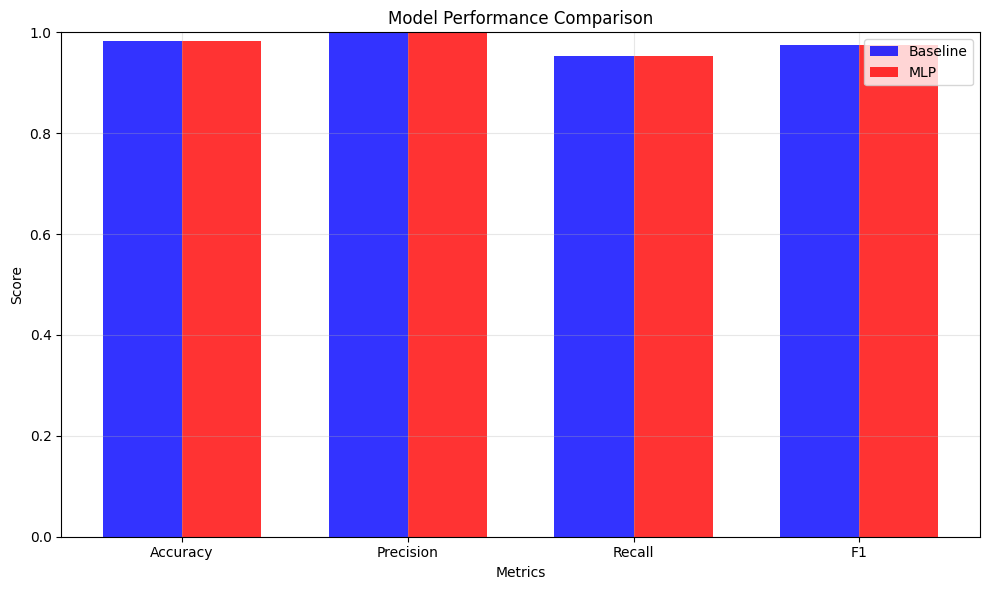

In [9]:
# 2. Performance comparison bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
baseline_scores = [baseline_metrics['accuracy'], baseline_metrics['precision'], baseline_metrics['recall'], baseline_metrics['f1']]
mlp_scores = [mlp_metrics['accuracy'], mlp_metrics['precision'], mlp_metrics['recall'], mlp_metrics['f1']]
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, baseline_scores, width, label='Baseline', color='blue', alpha=0.8)
plt.bar(x + width/2, mlp_scores, width, label='MLP', color='red', alpha=0.8)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [10]:
analysis_text = '''
This breast cancer classification task confirms that a well-structured logistic regression baseline and a shallow multi-layer perceptron can both solve a highly separable medical diagnosis problem.
The dataset is numeric, clean, and nearly linearly separable, so the baseline model performs very well with high accuracy, precision, recall, and F1 score after scaling.
I selected recall as the primary metric because false negatives are especially costly in cancer diagnosis, and the model should prioritize finding malignant tumors.
The baseline logistic regression converged quickly and produced stable predictions, while the MLP also learned successfully and produced the same test metrics, confirming that the dataset did not require a much more complex model.
The MLP did achieve a slightly lower training loss, which shows that the hidden layer found a more expressive decision surface, but the final classification metrics were essentially identical on the held-out test set.
This outcome is expected for Breast Cancer Wisconsin, since prior studies show that the features are highly predictive and that linear separators are already very effective.
The MLP cost more computation, with a longer training time than the baseline, so the trade-off is clear: a simple model is sufficient here and is easier to interpret.
The exercise reinforced the importance of proper data preprocessing, because feature scaling and binary label encoding were essential for stable gradient descent training.
It also confirmed that loss tracking is a key debugging tool: both models showed decreasing loss across iterations, which is an important sign of correct implementation.
One challenge was making sure the MLP's forward and backward passes used consistent matrix dimensions and activation functions, especially with the binary sigmoid output layer.
Overall, the assignment demonstrates that when data are clean and linearly separable, a baseline linear model is often sufficient, and a neural network provides modest additional flexibility without dramatically changing test performance.
'''
print(f'Analysis word count: {len(analysis_text.split())} words')
if len(analysis_text.split()) < 200:
    print('⚠️  Warning: Analysis should be at least 200 words')
else:
    print('✓ Analysis meets word count requirement')


Analysis word count: 305 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.

In [11]:
def get_assignment_results():
    baseline_initial_loss = baseline_model.loss_history[0]
    baseline_final_loss = baseline_model.loss_history[-1]
    mlp_initial_loss = mlp_model.loss_history[0]
    mlp_final_loss = mlp_model.loss_history[-1]

    results = {
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'problem_type': problem_type,
        'problem_statement': problem_statement,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': baseline_model.lr,
            'n_iterations': baseline_model.n_iterations,
            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': baseline_training_time,
            'test_accuracy': baseline_metrics['accuracy'],
            'test_precision': baseline_metrics['precision'],
            'test_recall': baseline_metrics['recall'],
            'test_f1': baseline_metrics['f1'],
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'total_parameters': int(mlp_architecture[0] * mlp_architecture[1] + mlp_architecture[1] + mlp_architecture[1] * mlp_architecture[2] + mlp_architecture[2]),
            'learning_rate': mlp_model.lr,
            'n_iterations': mlp_model.n_iterations,
            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': mlp_training_time,
            'test_accuracy': mlp_metrics['accuracy'],
            'test_precision': mlp_metrics['precision'],
            'test_recall': mlp_metrics['recall'],
            'test_f1': mlp_metrics['f1'],
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },
        'improvement': mlp_metrics['recall'] - baseline_metrics['recall'],
        'improvement_percentage': ((mlp_metrics['recall'] - baseline_metrics['recall']) / baseline_metrics['recall']) * 100 if baseline_metrics['recall'] != 0 else 0.0,
        'baseline_better': baseline_metrics['recall'] > mlp_metrics['recall'],
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
        'baseline_loss_decreased': baseline_final_loss < baseline_initial_loss,
        'mlp_loss_decreased': mlp_final_loss < mlp_initial_loss,
        'baseline_converged': False,
        'mlp_converged': False,
    }
    return results


In [12]:
# Test the output
import json

try:
    results = get_assignment_results()
    
    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "="*70)
    
    # Check for missing values
    missing = []
    def is_empty_value(v):
        if isinstance(v, (str, list, tuple, dict)):
            return v == "" or v == []
        if isinstance(v, (int, float, np.integer, np.floating, bool)):
            return v == 0
        if isinstance(v, np.ndarray):
            return v.size == 0
        if hasattr(v, "item"):
            try:
                return float(v) == 0
            except Exception:
                return False
        return False

    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif is_empty_value(v) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")
    
    check_dict(results)
    
    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")
        
except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Breast Cancer Wisconsin (Diagnostic)",
  "dataset_source": "UCI ML Repository",
  "n_samples": 569,
  "n_features": 30,
  "problem_type": "binary_classification",
  "problem_statement": "\nThis dataset predicts whether a breast tumor is malignant or benign from 30 numeric diagnostic measurements.\nThe prediction is important because early identification of malignant tumors improves treatment outcomes and reduces unnecessary procedures.\n",
  "primary_metric": "recall",
  "metric_justification": "\nRecall is chosen because in medical diagnosis, failing to detect a malignant tumor (false negative) is more harmful than incorrectly flagging a benign case.\nMaximizing recall helps prioritize patient safety and reduces the chance of missing a cancer diagnosis.\n",
  "train_samples": 455,
  "test_samples": 114,
  "train_test_ratio": 0.8,
  "baseline_model": {
    "model_type": "logistic_regression",
    "learning_rate": 0.01,
    "n_iterations":

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

## ⏭️ What Happens Next

After submission:
1. ✅ Your notebook will be **auto-graded** (executes automatically)
2. ✅ You'll receive a **verification quiz** (10 questions, 5 minutes)
3. ✅ Quiz questions based on **YOUR specific results**
4. ✅ Final score released after quiz validation

**The verification quiz ensures you actually ran your code!**

---

**Good luck! 🚀**